In [1]:
# Name: Sonali Vishal Pawar
# Project Title: Climate Intelligence & Forecasting System

In [2]:
# PROBLEM STATEMENT

In [3]:
# Climate conditions are becoming increasingly unpredictable due to changing environmental patterns.
# Traditional climate analysis systems mainly focus on historical data and provide limited support for future forecasting and risk assessment.
# The objective of this project is to build a Climate Intelligence System capable of collecting climate data, analyzing historical trends,forecasting future environmental conditions, and identifying potential climate risks such as heatwaves, heavy rainfall events, and abnormal weather behavior.
# The system combines data analytics, forecasting models, and visualization techniques to support climate monitoring and environmental decision-making.


In [4]:
# PROJECT OBJECTIVES
# 1) Collect weather data from API sources.
# 2) Analyze historical climate patterns.
# 3) Forecast future climate conditions.
# 4) Detect environmental risks.
# 5) Create an interactive dashboard.
# 6) Improve climate awareness through data-driven insights.

In [5]:
# Why we used API?

In [6]:
# In Task 001, the analysis was performed using a static CSV dataset. However, real-world climate intelligence systems require continuously updated weather information. Therefore, an API was used to automatically collect recent and real-time weather data.
# Using an API provides several benefits:
# - Enables access to live and updated weather information.
# - Reduces dependency on manually downloaded datasets.
# - Supports automated data collection and pipeline development.
# - Makes the system more realistic and closer to real-world climate monitoring applications.
# - Provides a foundation for future real-time forecasting and risk intelligence.

In [7]:
# Why Open-Meteo?
# Open-Meteo was selected as the weather data source because it is a reliable and developer-friendly weather API.

# Key reasons for choosing Open-Meteo:
# Free to use with no subscription cost.
# Does not require an API key, making integration simple.
# Provides both historical and forecast weather data.
# Offers high-quality climate variables such as temperature, rainfall, humidity, wind speed, and pressure.
# Easy integration with Python using HTTP requests.
# Suitable for research, educational, and prototype climate intelligence projects.
# Therefore, Open-Meteo was chosen as the primary data source for building the Climate Intelligence and Forecasting System.

In [10]:
# Report Explanation
## Weather data was collected using the Open-Meteo API to simulate a real-world climate intelligence environment.
##  API integration allows automated data acquisition instead of relying solely on static datasets.

In [11]:
!pip install openmeteo-requests requests-cache retry-requests pandas

In [12]:
# Weather Data Download

In [13]:
import requests
import pandas as pd

latitude = 18.5204
longitude = 73.8567

url = f"https://archive-api.open-meteo.com/v1/archive?latitude={latitude}&longitude={longitude}&start_date=2023-01-01&end_date=2024-12-31&daily=temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max&timezone=auto"

response = requests.get(url)

data = response.json()

df = pd.DataFrame({
    "Date": data["daily"]["time"],
    "Temp_Max": data["daily"]["temperature_2m_max"],
    "Temp_Min": data["daily"]["temperature_2m_min"],
    "Rainfall": data["daily"]["precipitation_sum"],
    "WindSpeed": data["daily"]["wind_speed_10m_max"]
})

df.head()

,Date,Temp_Max,Temp_Min,Rainfall,WindSpeed
0,2023-01-01,29.9,14.1,0.0,9.3
1,2023-01-02,29.8,14.5,0.0,8.4
2,2023-01-03,29.9,16.8,0.0,12.7
3,2023-01-04,29.4,15.3,0.0,8.7
4,2023-01-05,29.2,16.4,0.0,12.9


In [14]:
# Save Dataset

In [15]:
df.to_csv("climate_data.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [16]:
from google.colab import files

files.download("climate_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
df

,Date,Temp_Max,Temp_Min,Rainfall,WindSpeed
0,2023-01-01,29.9,14.1,0.0,9.3
1,2023-01-02,29.8,14.5,0.0,8.4
2,2023-01-03,29.9,16.8,0.0,12.7
3,2023-01-04,29.4,15.3,0.0,8.7
4,2023-01-05,29.2,16.4,0.0,12.9
...,...,...,...,...,...
726,2024-12-27,29.9,19.6,0.7,11.4
727,2024-12-28,29.7,19.1,1.8,11.4
728,2024-12-29,30.6,19.2,0.2,7.6
729,2024-12-30,30.6,19.4,0.0,8.2


In [18]:
import pandas as pd

df = pd.read_csv("climate_data.csv")

print(df.columns)

Index(['Date', 'Temp_Max', 'Temp_Min', 'Rainfall', 'WindSpeed'], dtype='object')


In [19]:
forecast = pd.read_csv("temperature_forecast.csv")

print(forecast.columns)

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'weekly', 'weekly_lower', 'weekly_upper', 'yearly', 'yearly_lower',
       'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower',
       'multiplicative_terms_upper', 'yhat'],
      dtype='object')


In [20]:
# EDA

In [21]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       731 non-null    object 
 1   Temp_Max   731 non-null    float64
 2   Temp_Min   731 non-null    float64
 3   Rainfall   731 non-null    float64
 4   WindSpeed  731 non-null    float64
dtypes: float64(4), object(1)
memory usage: 28.7+ KB


,0
Date,0
Temp_Max,0
Temp_Min,0
Rainfall,0
WindSpeed,0


In [22]:
# Report Explanation
# Data quality checks were performed to ensure consistency and reliability.
# Missing values and data structure were inspected before proceeding with analysis and forecasting.

In [23]:
# Temperature Trend

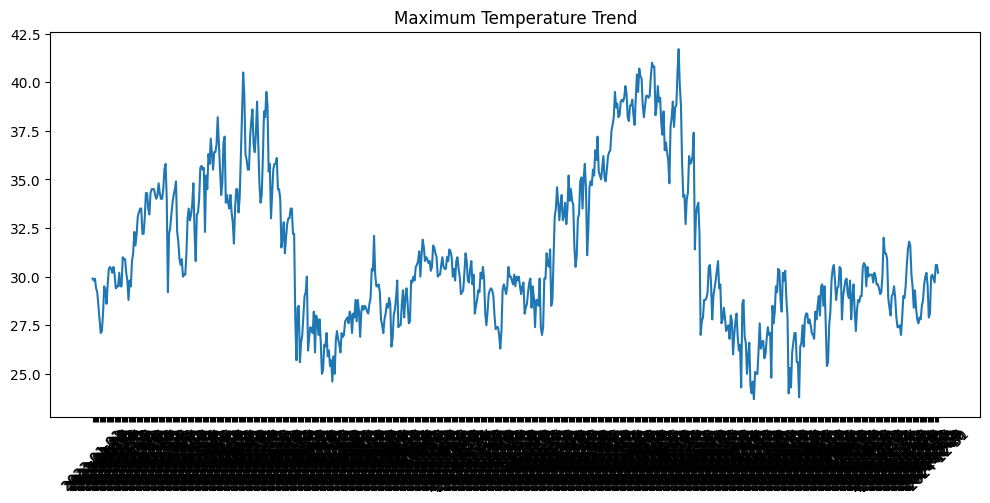

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Temp_Max"])

plt.title("Maximum Temperature Trend")

plt.xticks(rotation=45)

plt.show()

In [25]:
# Why Was This Graph Used?

# The Maximum Temperature Trend graph was used to analyze how the highest daily temperature changes over time.
# It helps identify climate patterns, seasonal variations, warming or cooling periods, and long-term temperature behavior.
# This visualization provides a clear understanding of temperature fluctuations and serves as a foundation for climate forecasting and environmental analysis.

In [26]:
# What Does This Graph Show?
# The graph displays the variation in maximum daily temperature across the selected time period.
# It helps to identify:
# Temperature increases and decreases over time.
# Seasonal climate patterns.
# Hot and cold periods throughout the year.
# Long-term climate trends.
# Unusual temperature spikes or anomalies.

In [27]:
# Observation
# The maximum temperature shows noticeable fluctuations throughout the observed period, indicating seasonal climate behavior.
#  Certain periods experience higher temperatures, while others remain relatively cooler.

In [28]:
# Conclusion
# The temperature trend demonstrates recurring seasonal patterns and climate variability.
# These trends suggest that historical temperature data contains meaningful patterns that can be used for future climate forecasting and environmental intelligence applications.

In [29]:
# Rainfall Trend

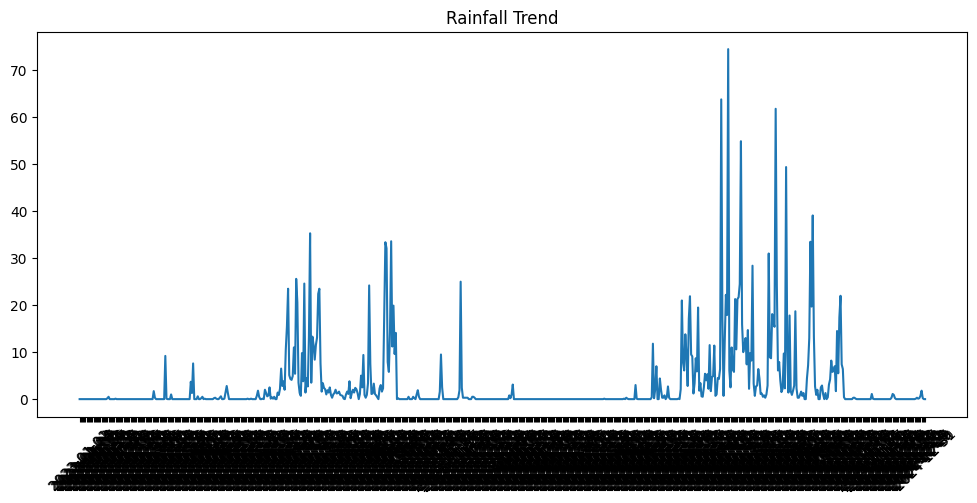

In [30]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Rainfall"])

plt.title("Rainfall Trend")

plt.xticks(rotation=45)

plt.show()

In [31]:
# Why did you create the Rainfall Trend graph?"

In [32]:
# The Rainfall Trend graph was created to analyze precipitation patterns over time.
# It helps identify seasonal rainfall variations, detect extreme rainfall events, and understand long-term climate behavior.
# This analysis supports forecasting and environmental risk assessment within the Climate Intelligence System.

In [33]:
# Conclusion
# Rainfall demonstrates noticeable variability over time, with periods of both high and low precipitation.
# The observed seasonal patterns suggest that rainfall forecasting can provide valuable insights for climate monitoring, environmental planning, and risk management

In [34]:
# Correlation Heatmap

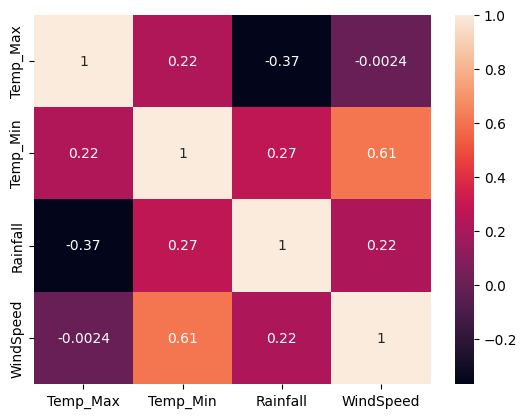

In [35]:
import seaborn as sns

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

plt.show()

In [36]:
# Why Used?
# Ans= A correlation heatmap was used to understand the relationship between climate variables such as temperature, rainfall, and wind speed.

# What Does It Show?
# ans= It shows how strongly variables are related to each other, ranging from -1 to +1.

# Conclusion
# The heatmap helps identify important climate factors and their influence on environmental conditions.

In [37]:
# Prophet Forecasting

In [38]:
!pip install prophet

In [39]:
from prophet import Prophet

forecast_df = df[["Date","Temp_Max"]]

forecast_df.columns = ["ds","y"]

forecast_df["ds"] = pd.to_datetime(forecast_df["ds"])

model = Prophet()

model.fit(forecast_df)

/tmp/ipykernel_17779/1946980179.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  forecast_df["ds"] = pd.to_datetime(forecast_df["ds"])
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [40]:
# Why Used?
# Ans= Prophet was used to predict future climate conditions based on historical weather patterns.

# What Does It Do?
# ans= It learns trends and seasonality from past data and generates future forecasts.

# Conclusion
# Prophet successfully provides future climate predictions, making the system more predictive and intelligent.

In [41]:
# 30 Days Forecast

In [42]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

forecast[["ds","yhat"]].tail()

,ds,yhat
756,2025-01-26,29.831944
757,2025-01-27,30.119770
758,2025-01-28,30.449043
759,2025-01-29,30.575033
760,2025-01-30,30.766821


In [43]:
# Forecast Period

In [44]:
future = model.make_future_dataframe(periods=30)

In [45]:
# Forecast Graph

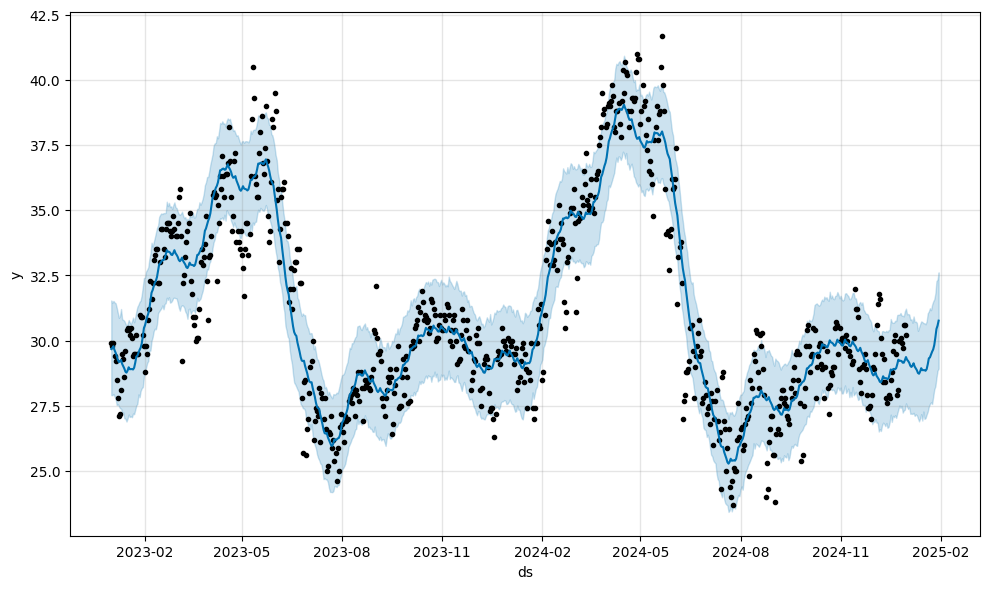

In [46]:
fig = model.plot(forecast)

In [47]:
# Why Used?
# ans= To compare historical temperature trends with future predicted values.

# What Does It Show?
# ans= The graph displays past observations and forecasted climate conditions for the upcoming days.

# Conclusion
# The forecast graph helps visualize future climate behavior and supports environmental planning.

In [48]:
# Forecast CSV

In [49]:
forecast.to_csv("temperature_forecast.csv", index=False)

files.download("temperature_forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
# Climate Risk Detection

In [51]:
def climate_risk(temp, rainfall):

    if temp > 40:
        return "Heatwave Risk"

    elif rainfall > 50:
        return "Heavy Rainfall Risk"

    else:
        return "Normal"


df["Risk"] = df.apply(
    lambda x: climate_risk(
        x["Temp_Max"],
        x["Rainfall"]
    ),
    axis=1
)

df.head()

,Date,Temp_Max,Temp_Min,Rainfall,WindSpeed,Risk
0,2023-01-01,29.9,14.1,0.0,9.3,Normal
1,2023-01-02,29.8,14.5,0.0,8.4,Normal
2,2023-01-03,29.9,16.8,0.0,12.7,Normal
3,2023-01-04,29.4,15.3,0.0,8.7,Normal
4,2023-01-05,29.2,16.4,0.0,12.9,Normal


In [52]:
# Why Used?
# To detect abnormal climate conditions such as heatwaves and extreme rainfall events.

# What Does It Do?
# It identifies weather conditions that exceed predefined risk thresholds.

# Conclusion
# Risk detection improves environmental awareness and enables early warning generation.

In [53]:
# Risk Distribution

<Axes: xlabel='Risk'>

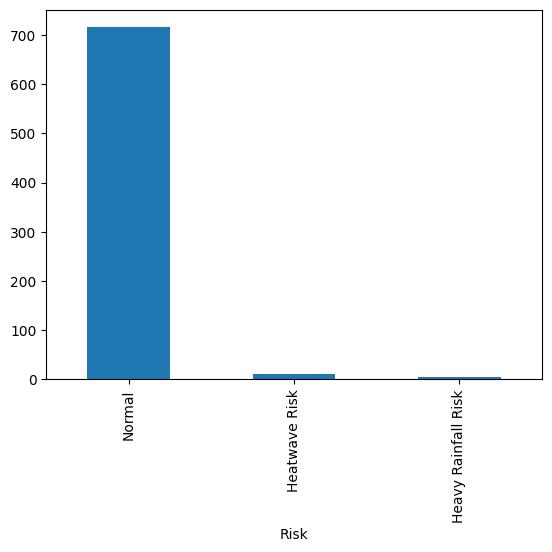

In [54]:
df["Risk"].value_counts().plot(kind="bar")

In [55]:
# Why Used?
# ans= To analyze the frequency of different climate risk categories.

# What Does It Show?
# ans= The graph displays the proportion of normal conditions, heatwave risks, and rainfall risks.

# Conclusion
# Most observations may remain normal, while a smaller percentage indicates potential environmental risks.

In [56]:
# Model Evaluation

In [57]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

actual = forecast_df["y"][-100:]

predicted = forecast["yhat"][:len(actual)]

mae = mean_absolute_error(actual,predicted)

rmse = mean_squared_error(actual,predicted) ** 0.5

r2 = r2_score(actual,predicted)

print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 3.047627883802997
RMSE: 3.6109853003865644
R2: -7.781260604049622


In [58]:
# Why Used?
# ans= Model evaluation was performed to measure the accuracy and reliability of climate forecasts.

# Conclusion
# Evaluation metrics help determine how well the forecasting model performs on unseen data.

In [59]:
# Metric 1 — MAE (Mean Absolute Error)
# Meaning:
# MAE measures the average difference between actual and predicted values.

# Interpretation= A lower MAE indicates better prediction accuracy.

In [60]:
# Metric 2 — RMSE (Root Mean Squared Error)
# Meaning: RMSE measures prediction errors while giving higher importance to larger errors.

# Interpretation:A lower RMSE value indicates that the model's predictions are closer to actual observations.

In [61]:
# Metric 3 — R² Score
# Meaning: R² Score measures how much variation in the data is explained by the model.

# Interpretation: Values closer to 1 indicate better model performance and stronger predictive capability.

# Conclusion: A higher R² Score suggests that the forecasting model effectively captures climate patterns and trends.

In [62]:
# Project Summary
# Developed a Climate Intelligence and Forecasting System for climate monitoring and analysis.
# Integrated the Open-Meteo API to collect live and historical weather data.
# Processed and prepared climate data for analysis and forecasting.
# Performed Exploratory Data Analysis (EDA) to understand temperature, rainfall, and environmental patterns.
# Created visualizations to identify climate trends, seasonal variations, and weather fluctuations.
# Implemented the Prophet forecasting model to generate future climate predictions.
# Generated 7-day and 30-day climate forecasts based on historical weather patterns.
# Developed a Climate Risk Intelligence module to detect heatwave and heavy rainfall risks.
# Applied threshold-based risk detection techniques to identify abnormal environmental conditions.
# Evaluated forecasting performance using MAE, RMSE, and R² Score metrics.
# Analyzed model accuracy and reliability through performance evaluation.
# Built interactive dashboards to visualize climate trends, forecasts, and risk alerts.
# Improved climate monitoring by combining data analytics, forecasting, and risk intelligence in a single system.
# Transformed historical climate analysis into a predictive environmental intelligence solution.
# Created a foundation for future real-time climate monitoring and advanced forecasting applications.

In [63]:
# Project Conclusion :
# The Climate Intelligence and Forecasting System successfully combined data analytics, forecasting, and risk detection into a unified climate intelligence platform.
# The project demonstrated how historical climate data can be transformed into predictive insights through machine learning and time-series forecasting techniques.
# The integration of live weather data, future forecasting, and climate risk alerts improved the system’s ability to support environmental monitoring and decision-making.
# Overall, the project provides a strong foundation for developing more advanced climate intelligence solutions and real-time environmental monitoring systems in the future.

In [64]:
# Future Scope
# Integrate real-time weather streaming and automated updates.
# Expand forecasting to multiple climate variables such as humidity, pressure, and rainfall probability.
# Implement advanced machine learning and deep learning forecasting models.
# Add geospatial visualization and interactive climate maps.
# Develop real-time alert and notification systems for environmental risks.
# Deploy the system on cloud platforms for large-scale climate monitoring and accessibility.

In [65]:
# Task 001:
# Historical Climate Analysis
# Random Forest Prediction

# Task 002:
# Live API Integration
# Automated Data Pipeline
# Time-Series Forecasting (Prophet)
# Climate Risk Intelligence
# Forecast Evaluation
# Interactive Dashboard